# Proyecto 2 - Entrega 2

## Modelos de regresion lineal

Nelson Escalante - 22046

### SETUP

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

#Variables clave
key_var = [
    'MSSubClass',
    'MSZoning',
    'LotArea',
    'Street',
    'Alley',
    'LandContour',
    'Utilities',
    'LotConfig',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'HouseStyle',
    'OverallQual',
    'OverallCond',
    'Exterior1st',
    'Exterior2nd',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'TotalBsmtSF',
    'Heating',
    'CentralAir',
    'GrLivArea',
    'FullBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Functional',
    'Fireplaces',
    'GarageType',
    'GarageArea',
    'GarageQual',
    'PoolArea',
    'MiscFeature'
]

train_path = "data/train.csv"
train = pd.read_csv(train_path)

numeric = train.select_dtypes(include=["number"]).columns
categ = train.select_dtypes(include=["object"]).columns

train[numeric] = train[numeric].fillna(train[numeric].median())

for col in categ:
    train[col] = train[col].fillna(train[col].mode()[0])

In [56]:
train.isnull().sum().sum()

np.int64(0)

In [57]:
#Separar variables de prediccion y la variable objetivo
x = train[key_var]
y = train["SalePrice"]

#Realizar el entrenamiento
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [58]:
#Filas en el conjunto de entrenamiento
x_train.shape[0]

1168

In [59]:
#Filas en el conjunto de prueba
x_test.shape[0]

292

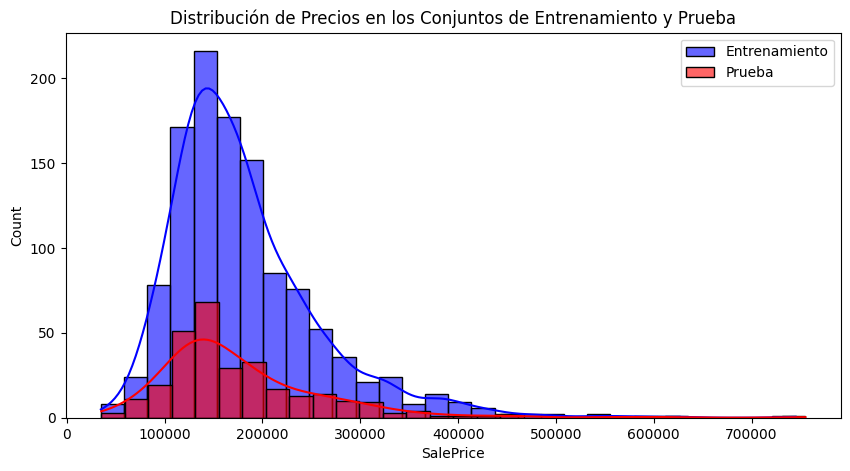

In [60]:
#Verificar distribucion
plt.figure(figsize=(10, 5))
sns.histplot(y_train, bins=30, kde=True, color="blue", label="Entrenamiento", alpha=0.6)
sns.histplot(y_test, bins=30, kde=True, color="red", label="Prueba", alpha=0.6)
plt.legend()
plt.title("Distribución de Precios en los Conjuntos de Entrenamiento y Prueba")
plt.show()

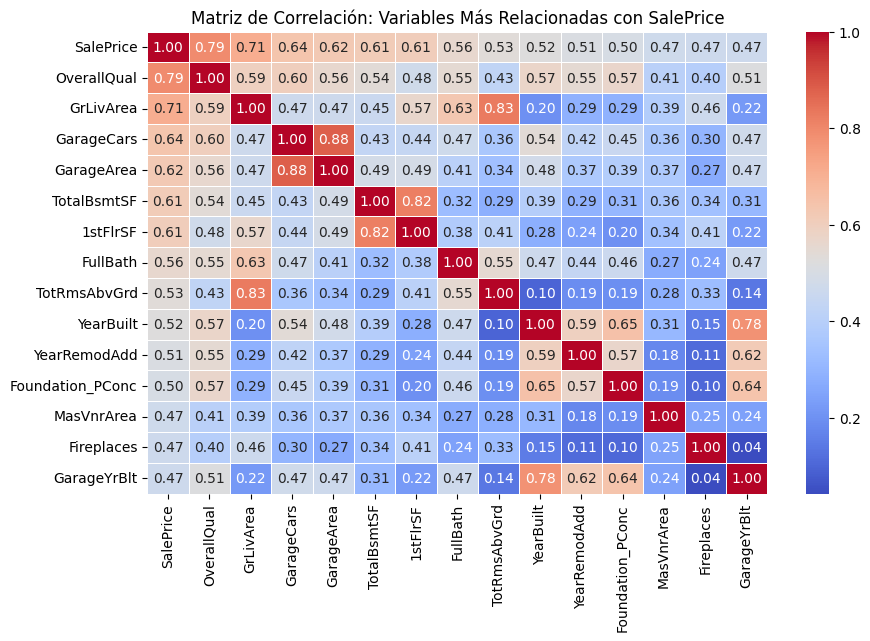

In [64]:
train = pd.get_dummies(train, drop_first=True)  # Convierte texto en números

orr_matrix = train.corr()

# Seleccionar solo las 15 variables más correlacionadas con SalePrice
top_corr_features = corr_matrix.nlargest(15, "SalePrice")["SalePrice"].index
corr_top = train[top_corr_features].corr()

# Graficar la correlación de estas variables
plt.figure(figsize=(10, 6))
sns.heatmap(corr_top, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación: Variables Más Relacionadas con SalePrice")
plt.show()

Las variables que se correlacionan mejor con 'SalePrice' son las siguientes:

- OverallQual
- GrLivArea
- GarageCars
- GarageArea
- TotalBsmtSF
- 1stFlrSF
- FullBath

Estas variables son nuestros mejores indicadores sobre los precios de las casas, y nos pueden servir para realizar el modelo de regresion lineal y predecir dichos precios.

Si lo analizamos, estas variables tienen sentido. Las personas que tengan mas carros pueden pagar mas por sus casas, por lo que el Garage nos sirve como buen indicador de precio. El tamanio en general de la casa, indicado por 'TotalBsmtSF' y '1stFlrSF', tambien nos sirve para saber los precios estimados de las casas.